In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Mixed precision: uses float16 for compute, float32 for weights → faster on GPU Tensor Cores
tf.keras.mixed_precision.set_global_policy('mixed_float16')

I0000 00:00:1781250745.629992  219693 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781250745.773377  219693 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781250748.662588  219693 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [4]:
import numpy as np

# Offline augmentation: horizontal flip → doubles training set 50k → 100k
flipped_images = train_images[:, :, ::-1, :]
flipped_labels = train_labels.copy()

train_images = np.concatenate([train_images, flipped_images], axis=0)
train_labels = np.concatenate([train_labels, flipped_labels], axis=0)

# Shuffle
idx = np.random.permutation(len(train_images))
train_images = train_images[idx]
train_labels = train_labels[idx]

print(f"Training set size after augmentation: {len(train_images)}")  # 100,000

Training set size after augmentation: 100000


In [ ]:
inputs = layers.Input(shape=(32, 32, 3))
# Input: shape=(32,32,3), 0 params

# Block 1
# Conv2D: 8 filters, (3x3), input channels=3 → output shape (32,32,8)
# Params: (3*3*3)*8 + 8 = 224
x = layers.Conv2D(8, (3, 3), padding='same')(inputs)
# BatchNorm: 8 params (gamma,beta), 8*2=16
x = layers.BatchNormalization()(x)
# ReLU: 0 params
x = layers.Activation('relu')(x)
# Conv2D: 16 filters, (3x3), input channels=8 → output shape (32,32,16)
# Params: (3*3*8)*16 + 16 = 1,168
x = layers.Conv2D(16, (3, 3), padding='same')(x)
# BatchNorm: 16*2=32
x = layers.BatchNormalization()(x)
# ReLU: 0 params
x = layers.Activation('relu')(x)
# MaxPooling2D: output shape (16,16,16), 0 params
x = layers.MaxPooling2D((2, 2))(x)

# Block 2 — with skip connection (projection shortcut 16 → 32)
# Skip connection projection: Conv2D: 32 filters, (1x1), input channels=16
# Params: (1*1*16)*32 + 32 = 544
skip = x
skip = layers.Conv2D(32, (1, 1), padding='same')(skip)
# BatchNorm: 32*2=64
skip = layers.BatchNormalization()(skip)

# Conv2D: 32 filters, (3x3), input channels=16 → (16,16,32)
# Params: (3*3*16)*32 + 32 = 4,640
x = layers.Conv2D(32, (3, 3), padding='same')(x)
# BatchNorm: 32*2=64
x = layers.BatchNormalization()(x)
# ReLU: 0 params
x = layers.Activation('relu')(x)

# Conv2D: 32 filters, (3x3), input channels=32
# Params: (3*3*32)*32 + 32 = 9,248
x = layers.Conv2D(32, (3, 3), padding='same')(x)
# BatchNorm: 32*2=64
x = layers.BatchNormalization()(x)
# Add: merges skip (32) and conv (32), 0 params
x = layers.Add()([x, skip])
# ReLU: 0 params
x = layers.Activation('relu')(x)
# MaxPooling2D: output shape (8,8,32), 0 params
x = layers.MaxPooling2D((2, 2))(x)

# Block 3 — with skip connection (projection shortcut 32 → 64)
# Skip connection projection: Conv2D: 64 filters, (1x1), input channels=32
# Params: (1*1*32)*64 + 64 = 2,112
skip = x
skip = layers.Conv2D(64, (1, 1), padding='same')(skip)
# BatchNorm: 64*2=128
skip = layers.BatchNormalization()(skip)

# Conv2D: 64 filters, (3x3), input channels=32
# Params: (3*3*32)*64 + 64 = 18,496
x = layers.Conv2D(64, (3, 3), padding='same')(x)
# BatchNorm: 64*2=128
x = layers.BatchNormalization()(x)
# ReLU: 0 params
x = layers.Activation('relu')(x)

# Conv2D: 64 filters, (3x3), input channels=64
# Params: (3*3*64)*64 + 64 = 36,928
x = layers.Conv2D(64, (3, 3), padding='same')(x)
# BatchNorm: 64*2=128
x = layers.BatchNormalization()(x)
# Add: merges skip (64) and conv (64), 0 params
x = layers.Add()([x, skip])
# ReLU: 0 params
x = layers.Activation('relu')(x)
# MaxPooling2D: output shape (4,4,64), 0 params
x = layers.MaxPooling2D((2, 2))(x)

# Classifier
# GlobalAveragePooling2D: shape (64,), 0 params
x = layers.GlobalAveragePooling2D()(x)
# Dropout: 0 params
x = layers.Dropout(0.1)(x)
# Dense: 10 units, input=64
# Params: 64*10 + 10 = 650
outputs = layers.Dense(10, dtype='float32')(x)

model = models.Model(inputs, outputs)
model.summary()

I0000 00:00:1781250758.449991  219693 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32, 8) │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32, 8) │         32 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      1,168 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        544 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                 

 Total params: 75,258 (293.98 KB)

 Trainable params: 74,634 (291.54 KB)

 Non-trainable params: 624 (2.44 KB)

In [6]:
# Model is fully defined in the cell above (Functional API with skip connection)

In [7]:
BATCH_SIZE = 512
# Linear LR scaling: larger batch needs proportionally higher LR
BASE_LR = 0.001 * (BATCH_SIZE / 32)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .cache()
    .shuffle(len(train_images), reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BASE_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50


I0000 00:00:1781250775.070920  219998 service.cc:153] XLA service 0x768970047de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781250775.070965  219998 service.cc:161]   StreamExecutor [0]: NVIDIA RTX 2000 Ada Generation Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781250775.189169  219998 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781250777.045522  219998 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781250777.303385  219998 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7637__.111


  7/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.7862  

I0000 00:00:1781250814.835966  219998 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


195/195 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 1.3645 - val_loss: 1.9462
Epoch 2/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.8972 - val_loss: 1.5475
Epoch 3/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.7260 - val_loss: 1.6564
Epoch 4/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.6248 - val_loss: 1.0895
Epoch 5/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.5624 - val_loss: 0.9246
Epoch 6/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.5166 - val_loss: 0.9401
Epoch 7/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4833 - val_loss: 0.6609
Epoch 8/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.4516 - val_loss: 1.6417
Epoch 9/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4265 - val_loss: 0.7004
Epoch 10/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4054 - val_loss: 1.2336
Epoch 11/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3903 - val_loss: 0.9801
Epoch 12/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/st

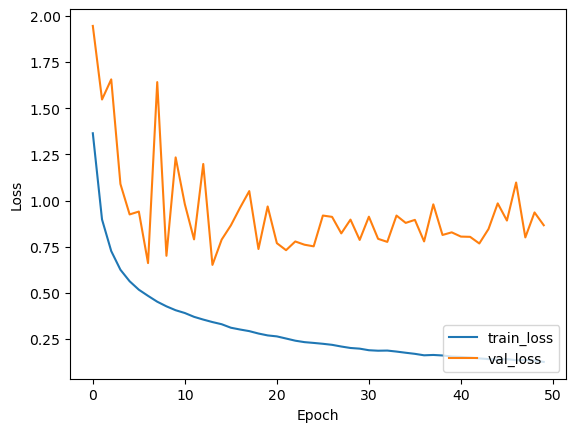

313/313 - 8s - 26ms/step - loss: 0.8660


In [8]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')
plt.show()

test_loss = model.evaluate(test_images,  test_labels, verbose=2)